# Bivariate Exploratory Data Analysis

## London Airbnb — Factors Associated with Top-Rated Listings

**Project Question:**  
Which listing and host features predict a top rating (4.8 or higher), so hosts know what to improve first?

### Objective

This notebook extends the univariate EDA by examining how individual listing and host characteristics are associated with `top_rated`.

For target-based comparisons, only listings with an observed rating are used. Unrated listings are retained in the cleaned dataset but are excluded from analyses involving `top_rated`.

Each analysis follows:

**Question → Visualization → Observation → Interpretation → Decision**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset produced by 01_cleaning.ipynb
df = pd.read_csv("../data/listings_clean.csv")

print("Full cleaned dataset:", df.shape)

Full cleaned dataset: (92635, 69)


In [2]:
# Use only listings with an observed rating for target-based analysis
rated = df[df["review_scores_rating"].notna()].copy()

print("Rated listings:", rated.shape)
print("\nTarget distribution:")
print(rated["top_rated"].value_counts())

print("\nTarget percentage:")
print((rated["top_rated"].value_counts(normalize=True) * 100).round(2))

Rated listings: (70708, 69)

Target distribution:
top_rated
1.0    39635
0.0    31073
Name: count, dtype: int64

Target percentage:
top_rated
1.0    56.05
0.0    43.95
Name: proportion, dtype: float64


## Bivariate Analysis

### 1. Price vs Top-Rated Status

**Question:** Are top-rated London Airbnb listings priced differently from non-top-rated listings?

Price is an important listing characteristic, but its distribution is highly right-skewed. The comparison therefore focuses on the typical price distribution while retaining the cleaned observations for analysis.

In [3]:
price_summary = (
    rated.groupby("top_rated")["price"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

price_summary.index = ["Not Top-Rated", "Top-Rated"]
price_summary

,count,mean,median,std
Not Top-Rated,22520,233.57,172.50,561.75
Top-Rated,26150,257.09,184.67,563.27


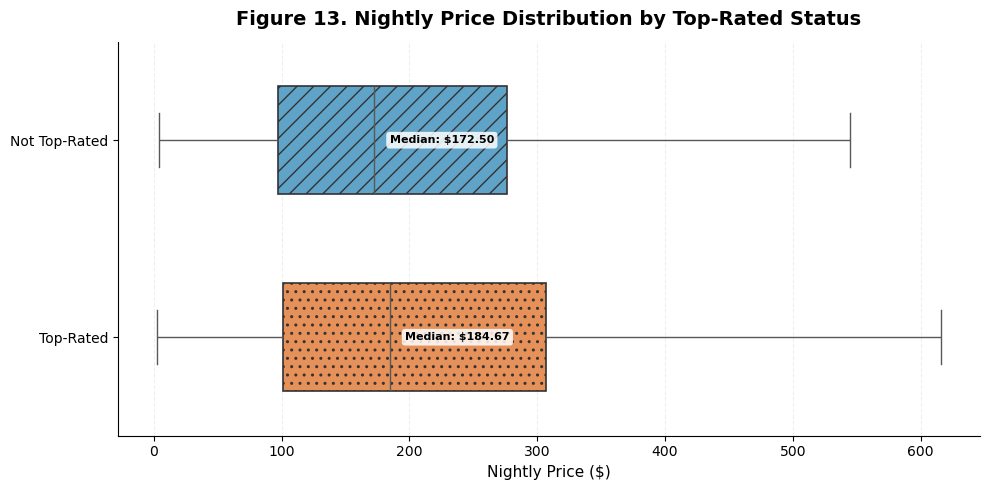

In [4]:
# Figure 13: Nightly price distribution by top-rated status

plot_data = rated[rated["price"].notna()].copy()

plot_data["Rating Status"] = plot_data["top_rated"].map({
    0: "Not Top-Rated",
    1: "Top-Rated"
})

order = ["Not Top-Rated", "Top-Rated"]

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=plot_data,
    x="price",
    y="Rating Status",
    hue="Rating Status",          # avoids Seaborn FutureWarning
    order=order,
    hue_order=order,
    palette={
        "Not Top-Rated": "#4DA8DA",
        "Top-Rated": "#FF8C42"
    },
    showfliers=False,
    legend=False,
    width=0.55,
    ax=ax
)

# Redundant patterns for grayscale readability
hatches = ["//", ".."]

for patch, hatch in zip(ax.patches, hatches):
    patch.set_hatch(hatch)
    patch.set_edgecolor("#333333")
    patch.set_linewidth(1.2)

# Calculate and display medians
medians = (
    plot_data.groupby("Rating Status")["price"]
    .median()
    .reindex(order)
)

for i, median in enumerate(medians):
    ax.text(
        median + 12,
        i,
        f"Median: ${median:,.2f}",
        va="center",
        ha="left",
        fontsize=8,
        fontweight="semibold",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="none",
            alpha=0.85
        )
    )

ax.set_title(
    "Figure 13. Nightly Price Distribution by Top-Rated Status",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Nightly Price ($)", fontsize=11)
ax.set_ylabel("")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.20
)

ax.grid(axis="y", visible=False)

sns.despine(ax=ax)

plt.tight_layout()

plt.savefig(
    "../figures/fig13_price_vs_top_rated.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

**Observation:**  
Among listings with available price data, top-rated listings have a median nightly price of **\$184.67**, compared with **\$172.50** for non-top-rated listings — approximately **7.1% higher**. However, the two price distributions overlap substantially.

**Interpretation:**  
Price shows some association with top-rated status, but the large overlap suggests that price alone is unlikely to distinguish top-rated listings reliably. The relationship should not be interpreted as higher prices causing higher ratings.

**Decision:**  
Retain `price` as a candidate feature for the classification model, but treat it as one of several predictors rather than a dominant feature. Because price is strongly right-skewed, consider a log transformation during model preprocessing.

### 2. Room Type vs Top-Rated Status

**Question:** Does the likelihood of being top-rated differ across Airbnb room types?

Room type represents the type of accommodation offered to guests. Comparing the proportion of top-rated listings within each room type helps determine whether accommodation type is associated with guest ratings.

In [5]:
room_summary = (
    rated.groupby("room_type")
    .agg(
        rated_listings=("top_rated", "size"),
        top_rated_listings=("top_rated", "sum"),
        top_rated_rate=("top_rated", "mean")
    )
)

room_summary["top_rated_rate_pct"] = (
    room_summary["top_rated_rate"] * 100
).round(2)

room_summary = (
    room_summary
    .sort_values("top_rated_rate_pct", ascending=False)
)

room_summary[
    ["rated_listings", "top_rated_listings", "top_rated_rate_pct"]
]

,rated_listings,top_rated_listings,top_rated_rate_pct
room_type,,,
Private room,22403,13002.0,58.04
Entire home/apt,48044,26563.0,55.29
Shared room,165,47.0,28.48
Hotel room,96,23.0,23.96


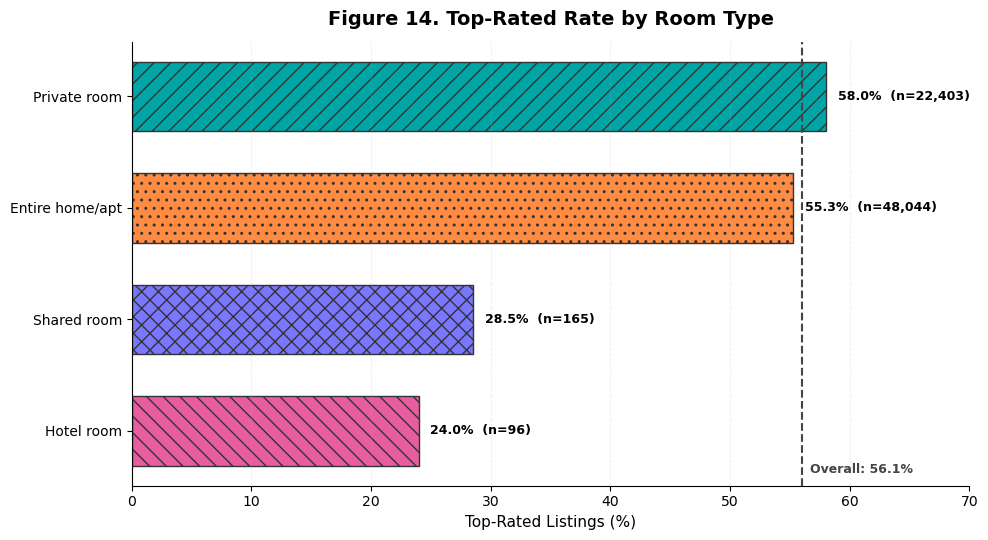

In [6]:
# Figure 14: Top-rated rate by room type

room_plot = (
    room_summary
    .reset_index()
    .sort_values("top_rated_rate_pct", ascending=False)
)

overall_rate = rated["top_rated"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5.5))

# Fresh categorical colors
colors = ["#00A6A6", "#FF8C42", "#7A77FF", "#E85D9E"]

bars = ax.barh(
    room_plot["room_type"],
    room_plot["top_rated_rate_pct"],
    color=colors,
    edgecolor="#333333",
    linewidth=1.0,
    height=0.62
)

# Different patterns for grayscale readability
hatches = ["//", "..", "xx", "\\\\"]

for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

# Percentage + sample-size labels
for bar, rate, n in zip(
    bars,
    room_plot["top_rated_rate_pct"],
    room_plot["rated_listings"]
):
    ax.text(
        rate + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}%  (n={n:,})",
        va="center",
        fontsize=9,
        fontweight="semibold"
    )

# Overall top-rated rate
ax.axvline(
    overall_rate,
    color="#444444",
    linestyle="--",
    linewidth=1.5
)

ax.text(
   overall_rate + 0.6,
    3.35,
    f"Overall: {overall_rate:.1f}%",
    fontsize=9,
    color="#444444",
    fontweight="semibold",
    va="center"
)

ax.set_title(
    "Figure 14. Top-Rated Rate by Room Type",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Top-Rated Listings (%)", fontsize=11)
ax.set_ylabel("")

ax.set_xlim(0, 70)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.20
)

ax.grid(axis="y", visible=False)

# Highest rate at top
ax.invert_yaxis()

sns.despine(ax=ax)

plt.tight_layout()

plt.savefig(
    "../figures/fig14_room_type_vs_top_rated.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

**Figure 14. Top-rated rate by room type.**  
The dashed line represents the overall top-rated rate among rated listings (**56.1%**). Sample sizes are shown beside each room type.

**Observation:**  
Private rooms have the highest top-rated rate (**58.0%**), followed closely by entire homes/apartments (**55.3%**). Shared rooms (**28.5%**) and hotel rooms (**24.0%**) show substantially lower rates.

**Interpretation:**  
Room type is associated with top-rated status, but the result requires careful interpretation. Private rooms and entire homes/apartments are supported by large samples (**22,403** and **48,044** rated listings), while shared rooms (**165**) and hotel rooms (**96**) have very small samples. Therefore, their much lower observed rates should not be generalized too strongly.

**Decision:**  
Retain `room_type` as a categorical candidate feature for the classification model. Encode it during preprocessing, while recognizing that estimates for the rare Shared room and Hotel room categories may be less stable because of their small sample sizes.

### 3. Listing Size vs Top-Rated Status

**Question:** Does the likelihood of being top-rated vary with the number of guests a listing accommodates?

`accommodates` represents listing capacity and provides a simple measure of listing size. Comparing top-rated rates across guest capacities can reveal whether smaller or larger listings show different rating patterns.

In [7]:
accommodates_summary = (
    rated[rated["accommodates"].notna()]
    .groupby("accommodates")
    .agg(
        rated_listings=("top_rated", "size"),
        top_rated_listings=("top_rated", "sum"),
        top_rated_rate=("top_rated", "mean")
    )
    .reset_index()
)

accommodates_summary["top_rated_rate_pct"] = (
    accommodates_summary["top_rated_rate"] * 100
).round(2)

accommodates_summary = accommodates_summary.sort_values("accommodates")

accommodates_summary[
    ["accommodates", "rated_listings",
     "top_rated_listings", "top_rated_rate_pct"]
]

,accommodates,rated_listings,top_rated_listings,top_rated_rate_pct
0,1,7022,4356.0,62.03
1,2,27303,15841.0,58.02
2,3,5577,2729.0,48.93
3,4,15333,8496.0,55.41
4,5,4199,2155.0,51.32
5,6,6373,3417.0,53.62
6,7,1372,727.0,52.99
7,8,1951,1088.0,55.77
8,9,401,211.0,52.62
9,10,593,326.0,54.97


In [8]:
# Group listing capacity to avoid unstable rates for rare high-capacity listings

capacity_data = rated[rated["accommodates"].notna()].copy()

capacity_data["Capacity Group"] = pd.cut(
    capacity_data["accommodates"],
    bins=[0, 2, 4, 6, np.inf],
    labels=["1–2 guests", "3–4 guests", "5–6 guests", "7+ guests"]
)

capacity_summary = (
    capacity_data.groupby("Capacity Group", observed=True)
    .agg(
        rated_listings=("top_rated", "size"),
        top_rated_listings=("top_rated", "sum"),
        top_rated_rate=("top_rated", "mean")
    )
    .reset_index()
)

capacity_summary["top_rated_rate_pct"] = (
    capacity_summary["top_rated_rate"] * 100
).round(2)

capacity_summary

,Capacity Group,rated_listings,top_rated_listings,top_rated_rate,top_rated_rate_pct
0,1–2 guests,34325,20197.0,0.588405,58.84
1,3–4 guests,20910,11225.0,0.536824,53.68
2,5–6 guests,10572,5572.0,0.527053,52.71
3,7+ guests,4901,2641.0,0.538870,53.89


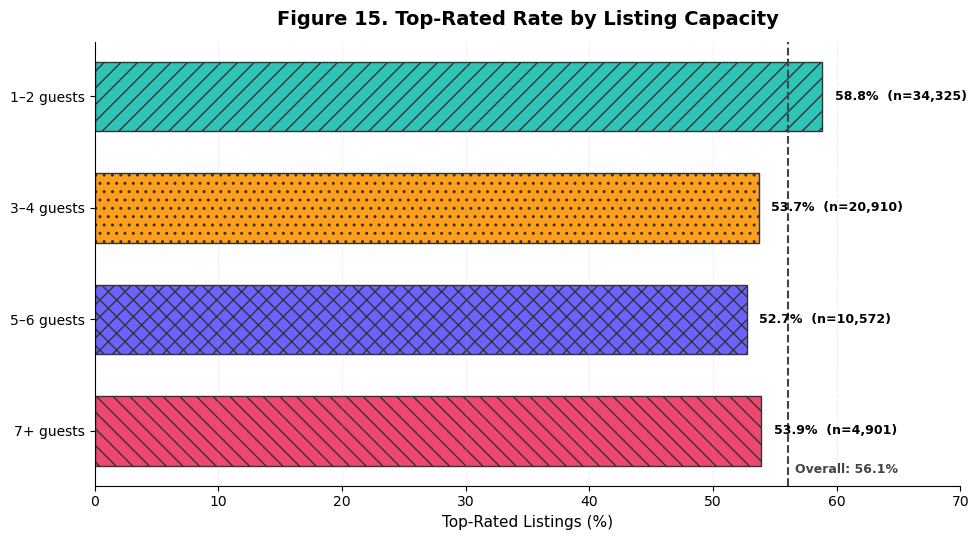

In [9]:
# Figure 15: Top-rated rate by listing capacity

overall_rate = rated["top_rated"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5.5))

colors = ["#2EC4B6", "#FF9F1C", "#6C63FF", "#EF476F"]
hatches = ["//", "..", "xx", "\\\\"]

bars = ax.barh(
    capacity_summary["Capacity Group"].astype(str),
    capacity_summary["top_rated_rate_pct"],
    color=colors,
    edgecolor="#333333",
    linewidth=1.0,
    height=0.62
)

# Redundant encoding for grayscale readability
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

# Percentage and sample-size labels
for bar, rate, n in zip(
    bars,
    capacity_summary["top_rated_rate_pct"],
    capacity_summary["rated_listings"]
):
    ax.text(
        rate + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}%  (n={n:,})",
        va="center",
        fontsize=9,
        fontweight="semibold"
    )

# Overall benchmark
ax.axvline(
    overall_rate,
    color="#444444",
    linestyle="--",
    linewidth=1.5
)

ax.text(
    overall_rate + 0.6,
    3.35,
    f"Overall: {overall_rate:.1f}%",
    fontsize=9,
    color="#444444",
    fontweight="semibold",
    va="center"
)

ax.set_title(
    "Figure 15. Top-Rated Rate by Listing Capacity",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Top-Rated Listings (%)", fontsize=11)
ax.set_ylabel("")

ax.set_xlim(0, 70)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.20
)

ax.grid(axis="y", visible=False)

# Keep capacity groups in natural order from small to large
ax.invert_yaxis()

sns.despine(ax=ax)

plt.tight_layout()

plt.savefig(
    "../figures/fig15_capacity_vs_top_rated.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

**Figure 15. Top-rated rate by listing capacity.**  
Listing capacities were grouped into 1–2, 3–4, 5–6, and 7+ guests to avoid unstable percentages for rare high-capacity values. The dashed line represents the overall top-rated rate among rated listings (**56.1%**).

**Observation:**  
Listings accommodating **1–2 guests** have the highest top-rated rate at **58.8%** (n=34,325), above the overall rate of 56.1%. The remaining capacity groups have lower and relatively similar top-rated rates: **53.7%** for 3–4 guests, **52.7%** for 5–6 guests, and **53.9%** for 7+ guests.

**Interpretation:**  
Smaller listings accommodating 1–2 guests show a modestly higher likelihood of being top-rated. Beyond two guests, the top-rated rate remains relatively stable at approximately 53–54%, suggesting that increasing listing capacity does not correspond to a consistent increase or decrease in top-rated status.

**Decision:**  
Retain `accommodates` as a candidate feature for the classification model. Because the relationship with top-rated status does not appear strictly linear, evaluate the original numeric feature and consider grouped or nonlinear representations during model development.

## Host Feature Selection
**Question:** Are available host characteristics associated with a listing's likelihood of being top-rated?

Host-related features may capture differences in host experience, verification, or listing management. Before selecting a feature for bivariate analysis, the available cleaned host variables are inspected to avoid using missing or target-leaking fields.

In [10]:
# Inspect host-related variables retained in the cleaned dataset

host_columns = [col for col in rated.columns if "host" in col.lower()]

host_check = pd.DataFrame({
    "dtype": rated[host_columns].dtypes.astype(str),
    "missing_pct": (rated[host_columns].isna().mean() * 100).round(2),
    "unique_values": rated[host_columns].nunique()
}).sort_values("missing_pct")

host_check

,dtype,missing_pct,unique_values
host_id,int64,0.00,40146
calculated_host_listings_count,int64,0.00,95
calculated_host_listings_count_private_rooms,int64,0.00,47
calculated_host_listings_count_entire_homes,int64,0.00,92
calculated_host_listings_count_shared_rooms,int64,0.00,11
hosts_time_as_user_months,float64,0.09,12
host_name,object,0.09,12970
host_profile_id,float64,0.09,40121
host_listings_count,float64,0.09,143
hosts_time_as_host_months,float64,0.09,12


### 4. Host Identity Verification vs Top-Rated Status

**Question:** Are listings from identity-verified hosts more likely to be top-rated?

Host identity verification is a platform-level host characteristic that may reflect trust and account completeness. Comparing top-rated rates between verified and non-verified hosts helps determine whether this characteristic is associated with guest ratings.

In [11]:
# Examine host identity verification vs top-rated status

identity_data = rated[
    rated["host_identity_verified"].notna()
].copy()

print("Host identity verification values:")
print(identity_data["host_identity_verified"].value_counts(dropna=False))

identity_summary = (
    identity_data
    .groupby("host_identity_verified")
    .agg(
        rated_listings=("top_rated", "size"),
        top_rated_listings=("top_rated", "sum"),
        top_rated_rate=("top_rated", "mean")
    )
    .reset_index()
)

identity_summary["top_rated_rate_pct"] = (
    identity_summary["top_rated_rate"] * 100
).round(2)

identity_summary

Host identity verification values:
host_identity_verified
t    69593
f     1051
Name: count, dtype: int64


,host_identity_verified,rated_listings,top_rated_listings,top_rated_rate,top_rated_rate_pct
0,f,1051,410.0,0.390105,39.01
1,t,69593,39199.0,0.563261,56.33


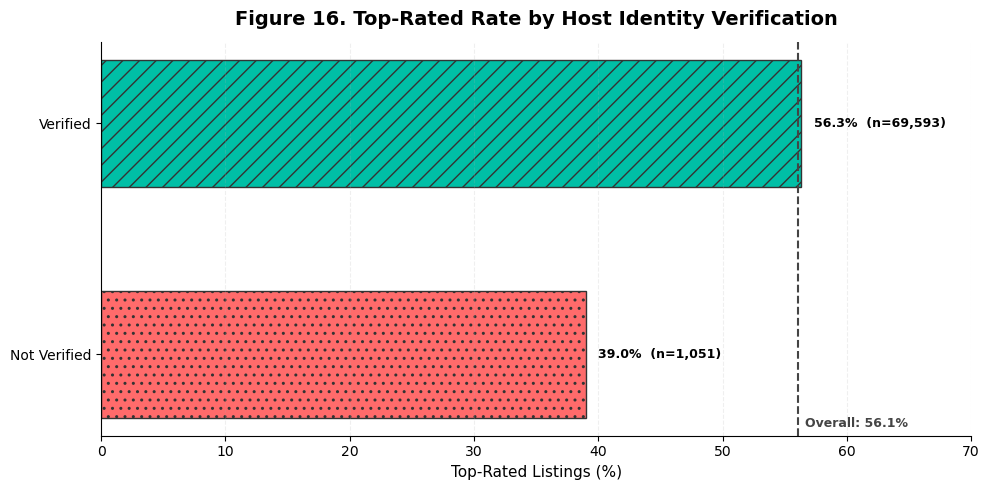

In [12]:
# Figure 16: Top-rated rate by host identity verification

identity_plot = identity_summary.copy()

identity_plot["Verification Status"] = (
    identity_plot["host_identity_verified"]
    .map({
        "f": "Not Verified",
        "t": "Verified"
    })
)

identity_plot = identity_plot.sort_values(
    "top_rated_rate_pct",
    ascending=False
)

overall_rate = rated["top_rated"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#00BFA6", "#FF6B6B"]
hatches = ["//", ".."]

bars = ax.barh(
    identity_plot["Verification Status"],
    identity_plot["top_rated_rate_pct"],
    color=colors,
    edgecolor="#333333",
    linewidth=1.0,
    height=0.55
)

# Redundant encoding for grayscale readability
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

# Percentage and sample-size labels
for bar, rate, n in zip(
    bars,
    identity_plot["top_rated_rate_pct"],
    identity_plot["rated_listings"]
):
    ax.text(
        rate + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}%  (n={n:,})",
        va="center",
        fontsize=9,
        fontweight="semibold"
    )

# Overall benchmark
ax.axvline(
    overall_rate,
    color="#444444",
    linestyle="--",
    linewidth=1.5
)

ax.text(
    overall_rate + 0.6,
    1.30,
    f"Overall: {overall_rate:.1f}%",
    fontsize=9,
    color="#444444",
    fontweight="semibold",
    va="center"
)

ax.set_title(
    "Figure 16. Top-Rated Rate by Host Identity Verification",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Top-Rated Listings (%)", fontsize=11)
ax.set_ylabel("")

ax.set_xlim(0, 70)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.20
)

ax.grid(axis="y", visible=False)

ax.invert_yaxis()

sns.despine(ax=ax)

plt.tight_layout()

plt.savefig(
    "../figures/fig16_identity_verification_vs_top_rated.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

**Figure 16. Top-rated rate by host identity verification.**  
The dashed line represents the overall top-rated rate among rated listings (**56.1%**). Sample sizes are shown for both verification groups.

**Observation:**  
Listings from identity-verified hosts have a top-rated rate of **56.3%** (n=69,593), compared with **39.0%** (n=1,051) for listings from non-verified hosts — a difference of approximately **17.3 percentage points**.

**Interpretation:**  
Host identity verification is associated with a substantially higher observed top-rated rate. However, the groups are highly imbalanced: approximately **98.5%** of listings in this comparison belong to verified hosts. Therefore, the result should be interpreted as an association rather than evidence that verification itself causes higher ratings.

**Decision:**  
Retain `host_identity_verified` as a candidate categorical feature for the classification model. Because the non-verified group is relatively small, evaluate its predictive contribution during model validation rather than assuming that the large observed rate difference will translate directly into strong predictive performance.

### 5. Host Experience vs Top-Rated Status

**Question:** Does the likelihood of being top-rated vary with host experience?

Host tenure provides a measure of how long a host has been active on Airbnb. Examining top-rated rates across host experience levels can help determine whether longer platform experience is associated with higher guest ratings.

In [13]:
# Examine host experience vs top-rated status

experience_data = rated[
    rated["hosts_time_as_host_years"].notna()
].copy()

experience_summary = (
    experience_data
    .groupby("hosts_time_as_host_years")
    .agg(
        rated_listings=("top_rated", "size"),
        top_rated_listings=("top_rated", "sum"),
        top_rated_rate=("top_rated", "mean")
    )
    .reset_index()
    .sort_values("hosts_time_as_host_years")
)

experience_summary["top_rated_rate_pct"] = (
    experience_summary["top_rated_rate"] * 100
).round(2)

experience_summary[
    [
        "hosts_time_as_host_years",
        "rated_listings",
        "top_rated_listings",
        "top_rated_rate_pct"
    ]
]

,hosts_time_as_host_years,rated_listings,top_rated_listings,top_rated_rate_pct
0,0.0,5354,3367.0,62.89
1,1.0,6772,3822.0,56.44
2,2.0,8141,4458.0,54.76
3,3.0,7149,3967.0,55.49
4,4.0,4048,2175.0,53.73
5,5.0,2064,1036.0,50.19
6,6.0,4159,2247.0,54.03
7,7.0,5764,3293.0,57.13
8,8.0,5675,3262.0,57.48
9,9.0,6307,3473.0,55.07


In [14]:
# Group host tenure into broader experience levels

experience_data["Experience Group"] = pd.cut(
    experience_data["hosts_time_as_host_years"],
    bins=[-1, 2, 5, 8, 11, np.inf],
    labels=[
        "0–2 years",
        "3–5 years",
        "6–8 years",
        "9–11 years",
        "12+ years"
    ]
)

experience_group_summary = (
    experience_data
    .groupby("Experience Group", observed=True)
    .agg(
        rated_listings=("top_rated", "size"),
        top_rated_listings=("top_rated", "sum"),
        top_rated_rate=("top_rated", "mean")
    )
    .reset_index()
)

experience_group_summary["top_rated_rate_pct"] = (
    experience_group_summary["top_rated_rate"] * 100
).round(2)

experience_group_summary

,Experience Group,rated_listings,top_rated_listings,top_rated_rate,top_rated_rate_pct
0,0–2 years,20267,11647.0,0.574678,57.47
1,3–5 years,13261,7178.0,0.541286,54.13
2,6–8 years,15598,8802.0,0.564303,56.43
3,9–11 years,16586,9130.0,0.550464,55.05
4,12+ years,4931,2851.0,0.578179,57.82


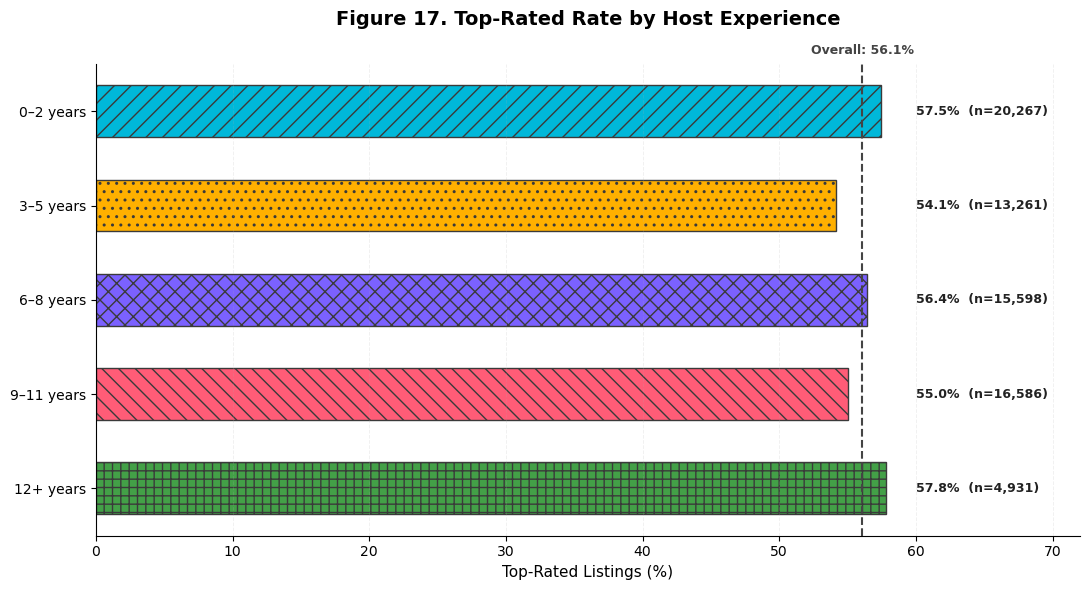

In [15]:
# Figure 17: Top-rated rate by host experience

plot_data = experience_group_summary.copy()

overall_rate = rated["top_rated"].mean() * 100

fig, ax = plt.subplots(figsize=(11, 6))

# Five clearly distinct, fresh colors
colors = [
    "#00B8D9",   # cyan-blue
    "#FFB000",   # golden orange
    "#7B61FF",   # purple
    "#FF5C77",   # coral pink
    "#43A047"    # green
]

# Different patterns for grayscale readability
hatches = ["//", "..", "xx", "\\\\", "++"]

bars = ax.barh(
    plot_data["Experience Group"],
    plot_data["top_rated_rate_pct"],
    color=colors,
    edgecolor="#3A3A3A",
    linewidth=1.0,
    height=0.55
)

# Apply hatch patterns
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

# Keep all labels aligned in one column
label_x = 60.0

for bar, rate, n in zip(
    bars,
    plot_data["top_rated_rate_pct"],
    plot_data["rated_listings"]
):
    ax.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}%  (n={n:,})",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="semibold",
        color="#222222"
    )

# Overall benchmark line
ax.axvline(
    overall_rate,
    color="#444444",
    linestyle="--",
    linewidth=1.5,
    zorder=3
)

# Put benchmark label ABOVE the plotting area
ax.text(
    overall_rate,
    1.015,
    f"Overall: {overall_rate:.1f}%",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="bottom",
    fontsize=9,
    fontweight="semibold",
    color="#444444"
)

# Title
ax.set_title(
    "Figure 17. Top-Rated Rate by Host Experience",
    fontsize=14,
    fontweight="bold",
    pad=28
)

ax.set_xlabel(
    "Top-Rated Listings (%)",
    fontsize=11
)

ax.set_ylabel("")

# Extra space on right for labels
ax.set_xlim(0, 72)

# Light gridlines
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.18
)

ax.grid(axis="y", visible=False)

# Keep experience order from newest to longest
ax.invert_yaxis()

sns.despine(ax=ax)

plt.tight_layout()

plt.savefig(
    "../figures/fig17_host_experience_vs_top_rated.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

**Figure 17. Top-rated rate by host experience.**  
Host tenure was grouped into broader experience ranges to reduce year-to-year noise and provide more stable comparisons. The dashed line represents the overall top-rated rate among rated listings (**56.1%**).

**Observation:**  
Top-rated rates vary only modestly across host experience groups, ranging from **54.1% to 57.8%**. Hosts with **12+ years** of experience have the highest observed rate (**57.8%**, n=4,931), followed closely by hosts with **0–2 years** of experience (**57.5%**, n=20,267). The **3–5 year** group has the lowest rate at **54.1%**.

**Interpretation:**  
There is no consistent increase in top-rated status as host experience increases. Both newer and long-tenured hosts show relatively high rates, while intermediate experience groups fluctuate around the overall rate. This suggests that host tenure alone has a limited and potentially nonlinear relationship with top-rated status.

**Decision:**  
Retain `hosts_time_as_host_years` as a candidate feature for model evaluation, but do not assume a linear effect. Compare its predictive contribution using an appropriate nonlinear model or grouped representation during model development.